<a href="https://colab.research.google.com/github/muhammadhasbiashiddiqi/PCVK_Genap_2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [36]:
def convolution2d(image, kernel, stride=1, padding=0):
    # Penambahan zero padding pada citra masukan
    if padding > 0:
        image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Menghitung dimensi output
    out_h = int((img_h - k_h) / stride) + 1
    out_w = int((img_w - k_w) / stride) + 1

    output = np.zeros((out_h, out_w))

    for y in range(0, out_h):
        for x in range(0, out_w):
            # Mengambil sub-matriks citra seluas kernel
            sub_matrix = image[y*stride : y*stride + k_h, x*stride : x*stride + k_w]
            # Melakukan perkalian elemen-demi-elemen lalu menjumlahkannya
            output[y, x] = np.sum(sub_matrix * kernel)

    return output

In [37]:
img_path = '/content/drive/MyDrive/PCVK/Gambar/mandrill.jpg'
img = cv.imread(img_path)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [38]:
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

kernel_emboss = np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [ 0,  1, 2]])

kernel_left_sobel = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])

kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])

In [39]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel_21x21 = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

In [48]:
res_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
res_emboss = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
res_sobel = convolution2d(img_gray, kernel_left_sobel, stride=1, padding=1)
res_canny = convolution2d(img_gray, kernel_canny, stride=1, padding=1)
res_gauss = convolution2d(img_gray, gauss_kernel_21x21, stride=1, padding=10)

NameError: name 'kernel_sobel' is not defined

In [42]:
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img_item, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img_item.shape) == 2:  # Grayscale
            plt.imshow(img_item, cmap="gray")
        else:  # Color (BGR to RGB)
            plt.imshow(cv.cvtColor(img_item, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

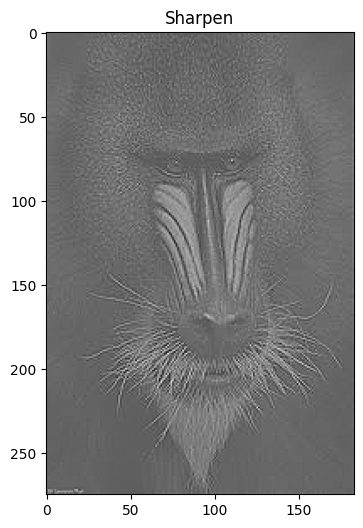

In [43]:
plt.figure(figsize=(6, 6))
plt.imshow(res_sharpen, cmap='gray')
plt.title('Sharpen')
plt.show()

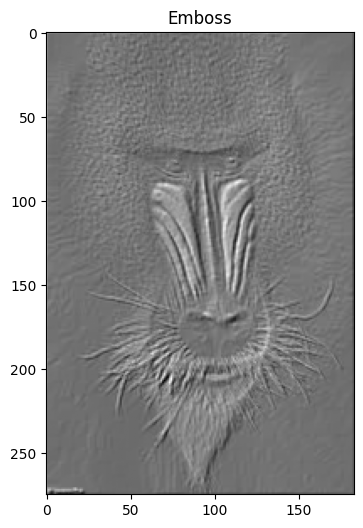

In [44]:
plt.figure(figsize=(6, 6))
plt.imshow(res_emboss, cmap='gray')
plt.title('Emboss')
plt.show()

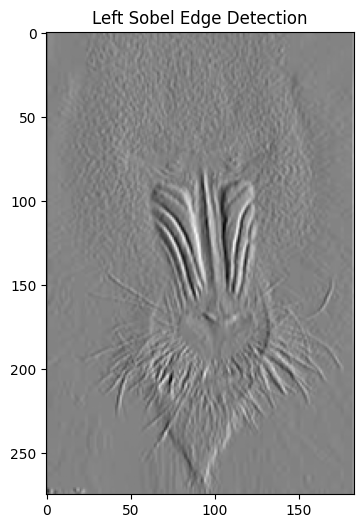

In [45]:
plt.figure(figsize=(6, 6))
plt.imshow(res_sobel, cmap='gray')
plt.title('Left Sobel Edge Detection')
plt.show()

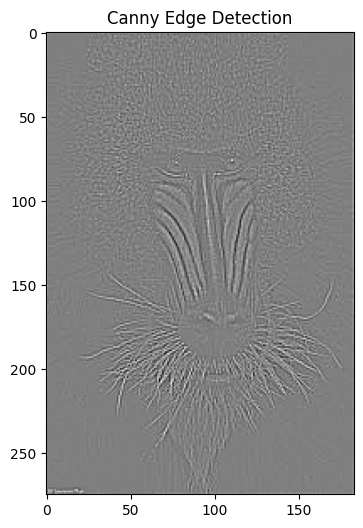

In [46]:
plt.figure(figsize=(6, 6))
plt.imshow(res_canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.show()

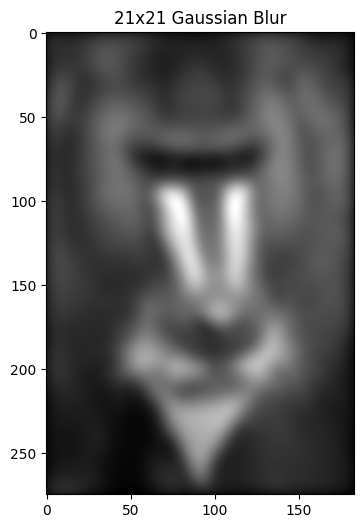

In [50]:
plt.figure(figsize=(6, 6))
plt.imshow(res_gauss, cmap='gray')
plt.title('21x21 Gaussian Blur')
plt.show()

In [55]:
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img_item, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img_item.shape) == 2:  # Grayscale
            plt.imshow(img_item, cmap="gray")
        else:  # Color (BGR to RGB)
            plt.imshow(cv.cvtColor(img_item, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

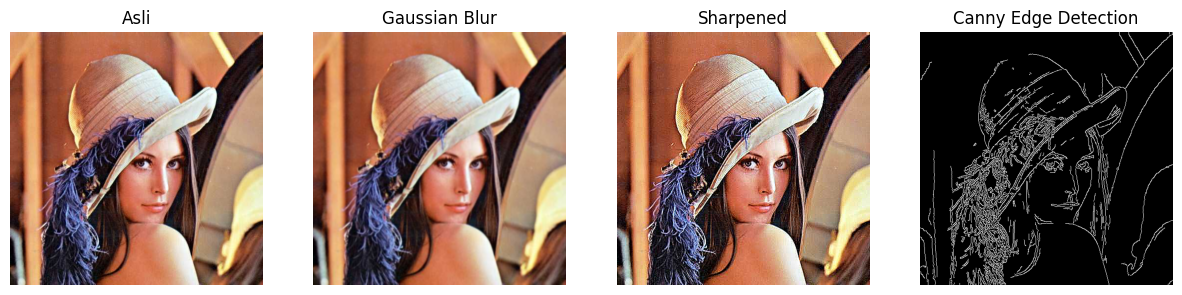

In [58]:
img_lena = cv.imread("/content/drive/MyDrive/PCVK/Gambar/Lena.jpeg")

blur = cv.GaussianBlur(img_lena, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img_lena, -1, sharpen_kernel)

show_side_by_side([img_lena, blur, sharpened, edges],
                   ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

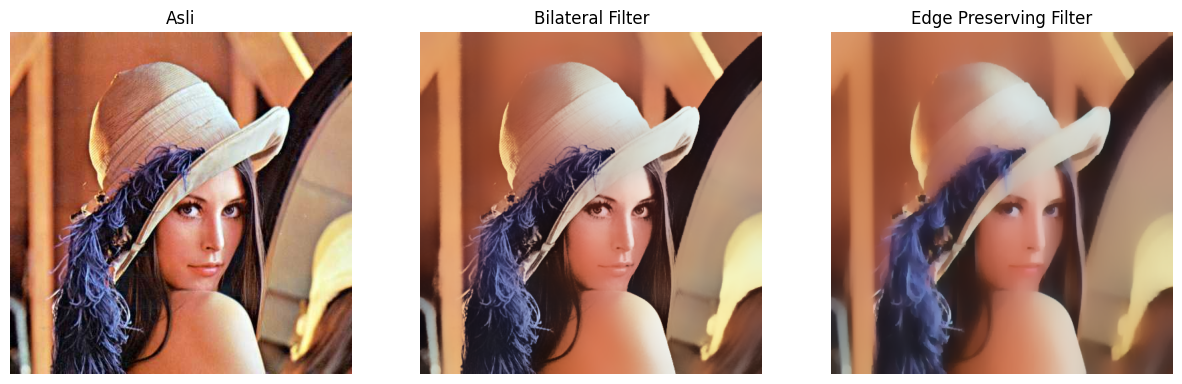

In [59]:
bilateral = cv.bilateralFilter(img_lena, 50, 100, 100)
edge_preserve = cv.edgePreservingFilter(img_lena, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img_lena, bilateral, edge_preserve],
                   ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

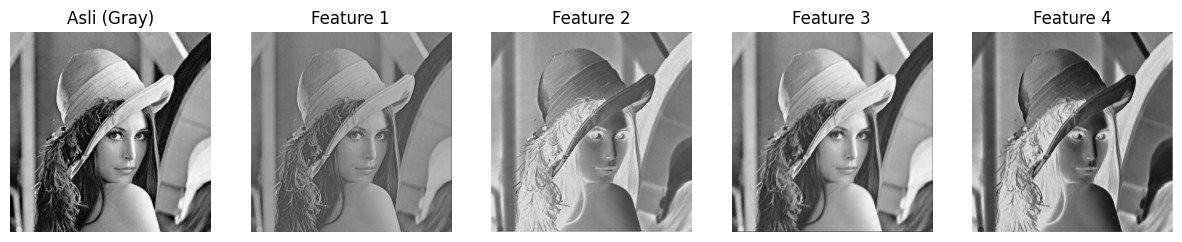

In [61]:
import torch
import torch.nn as nn
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

img_lena_gray = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)
img_tensor = torch.tensor(img_lena_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
    features = model(img_tensor)

feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_lena_gray] + feature_maps,
                   ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

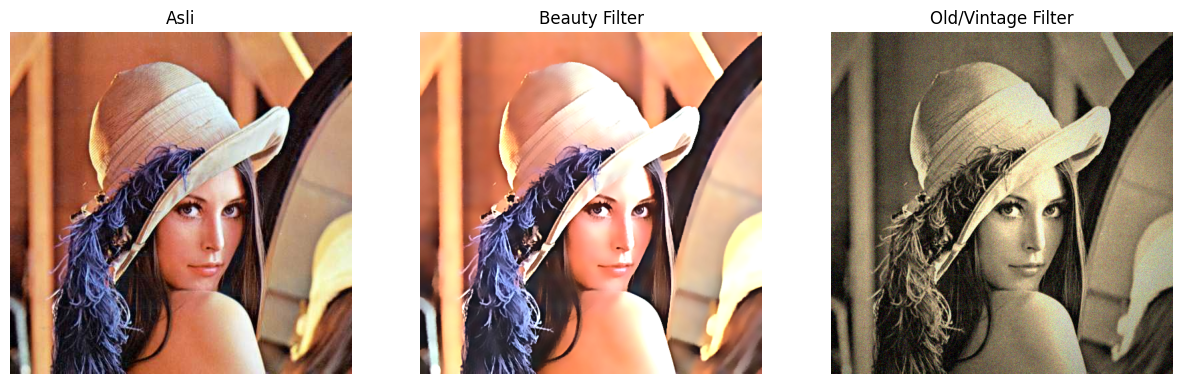

In [62]:
# 1. Beauty Filter
smooth = cv.bilateralFilter(img_lena, d=15, sigmaColor=75, sigmaSpace=75)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened_beauty = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)
beauty = cv.convertScaleAbs(sharpened_beauty, alpha=1.2, beta=15)

# 2. Old/Vintage Filter
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img_lena, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img_lena.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel_vignette = kernel_y * kernel_x.T
mask = kernel_vignette / kernel_vignette.max()

vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img_lena, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

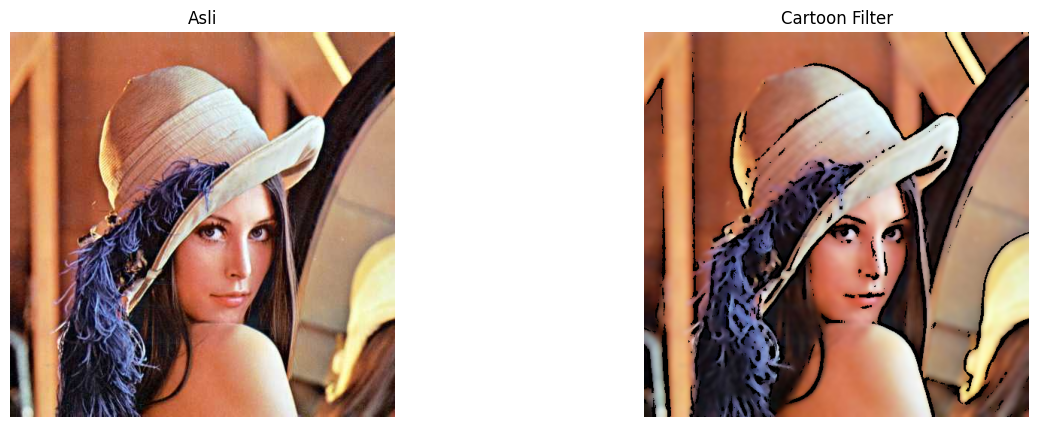

In [63]:
gray_c = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray_c, 7)
edges_c = cv.adaptiveThreshold(gray_blur, 255,
                                cv.ADAPTIVE_THRESH_MEAN_C,
                                cv.THRESH_BINARY, 9, 9)

color_c = cv.bilateralFilter(img_lena, d=9, sigmaColor=200, sigmaSpace=200)
cartoon = cv.bitwise_and(color_c, color_c, mask=edges_c)

show_side_by_side([img_lena, cartoon], ["Asli", "Cartoon Filter"])

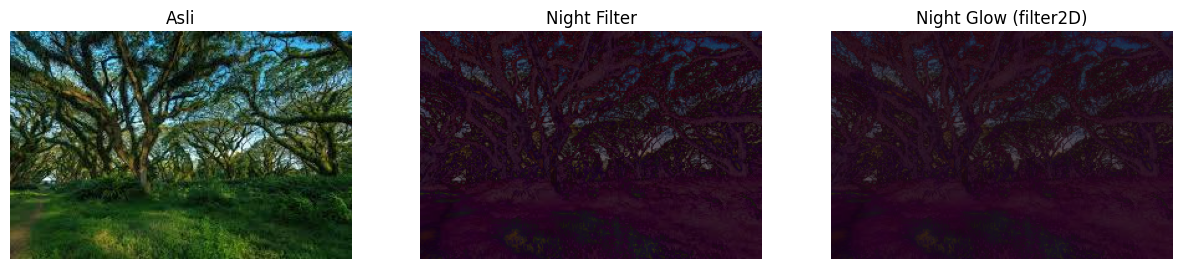

In [65]:
img_djawatan = cv.imread("/content/drive/MyDrive/PCVK/Gambar/djawatan.jpg")

night = cv.convertScaleAbs(img_djawatan, alpha=0.6, beta=-40)
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel_glow = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel_glow)
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_djawatan, night, night_glow],
                   ["Asli", "Night Filter", "Night Glow (filter2D)"])

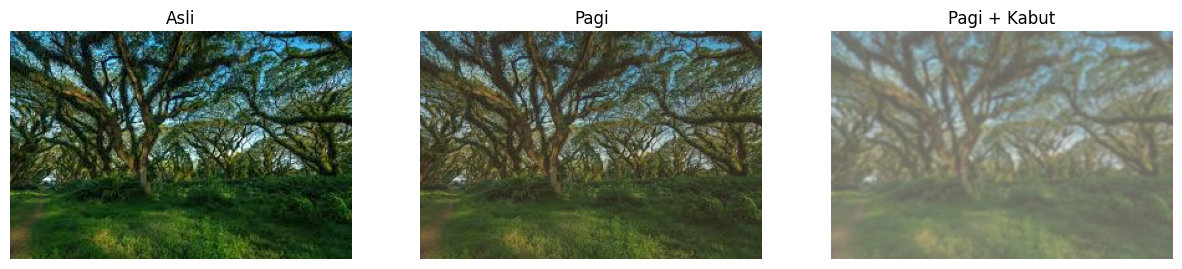

In [66]:
soft_pagi = cv.convertScaleAbs(img_djawatan, alpha=0.9, beta=20)
warm_tint = np.full_like(soft_pagi, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft_pagi, 0.8, warm_tint, 0.2, 0)

kernel_haze_1d = cv.getGaussianKernel(3, 3)
kernel_haze = kernel_haze_1d @ kernel_haze_1d.T
kabut = cv.filter2D(pagi, -1, kernel_haze)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_djawatan, pagi, kabut],
                   ["Asli", "Pagi", "Pagi + Kabut"])

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

In [74]:
def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy_image = np.copy(image)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255

    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    return noisy_image

In [75]:
noisy_img = add_salt_and_pepper_noise(img_gray, salt_prob=0.02, pepper_prob=0.02)
mean_filtered = cv.blur(noisy_img, (3, 3))
median_filtered = cv.medianBlur(noisy_img, 3)

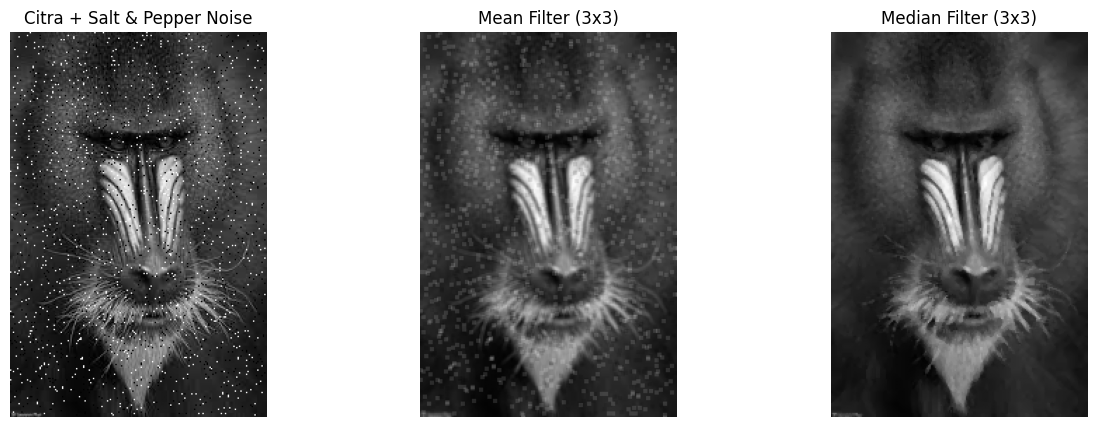

In [76]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Citra + Salt & Pepper Noise")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mean_filtered, cmap='gray')
plt.title("Mean Filter (3x3)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(median_filtered, cmap='gray')
plt.title("Median Filter (3x3)")
plt.axis("off")

plt.show()

In [77]:
blurry_img = cv.GaussianBlur(img_gray, (5, 5), 0)

In [78]:
kernel_sharp_3x3 = np.array([[ 0, -1,  0],
                             [-1,  5, -1],
                             [ 0, -1,  0]])

kernel_sharp_5x5 = np.array([[-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, 25, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1]])

In [79]:
sharp_3x3 = cv.filter2D(blurry_img, -1, kernel_sharp_3x3)
sharp_5x5 = cv.filter2D(blurry_img, -1, kernel_sharp_5x5)

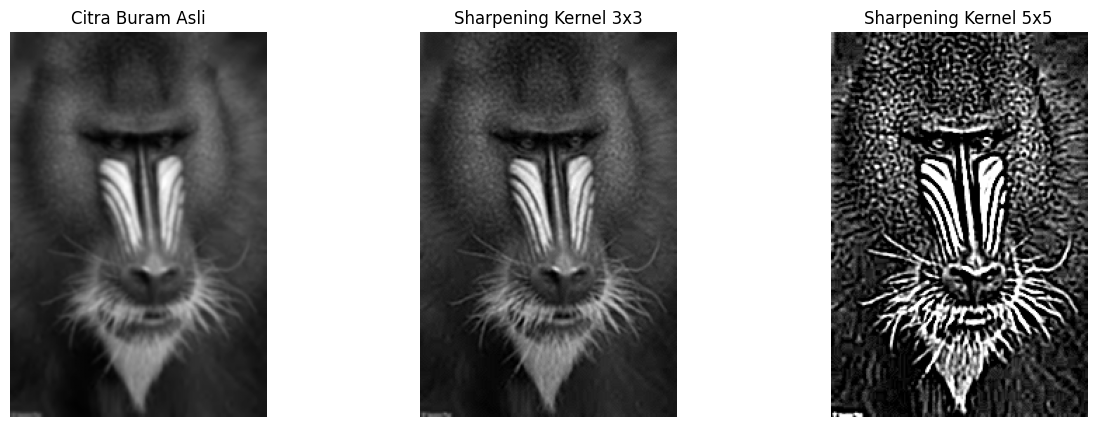

In [80]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(blurry_img, cmap='gray')
plt.title("Citra Buram Asli")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sharp_3x3, cmap='gray')
plt.title("Sharpening Kernel 3x3")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp_5x5, cmap='gray')
plt.title("Sharpening Kernel 5x5")
plt.axis("off")

plt.show()

In [81]:
def kartun(image):
    if len(image.shape) == 3:
        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

In [84]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

In [87]:
def kartun(image):
    if len(image.shape) == 3:
        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    if len(image.shape) == 3:
        color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)
        cartoon_img = cv.bitwise_and(color, color, mask=edges)
    else:
        color = cv.bilateralFilter(gray, d=9, sigmaColor=200, sigmaSpace=200)
        cartoon_img = cv.bitwise_and(color, color, mask=edges)

    return cartoon_img

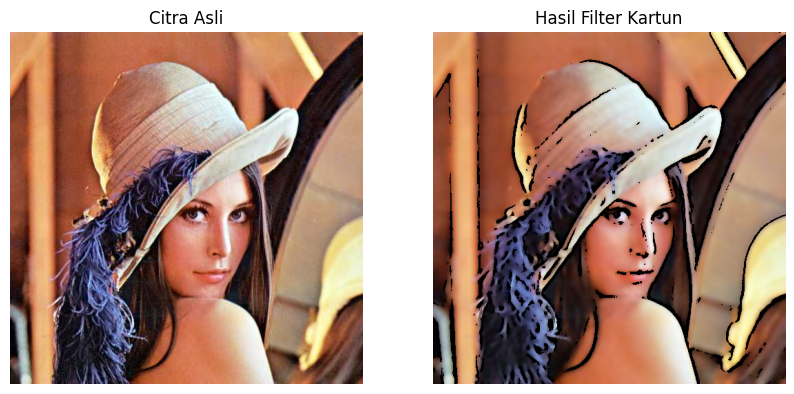

In [88]:
hasil_kartun = kartun(img_lena)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_lena, cv.COLOR_BGR2RGB))
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(hasil_kartun, cv.COLOR_BGR2RGB))
plt.title("Hasil Filter Kartun")
plt.axis("off")

plt.show()